In [1]:
"""
Task 1: MPC-based Battery Schedule -- Objective Implementation
"""

import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import pandas as pd

# ==============================================================================
# Load, generation, and tariffs
# ==============================================================================
def read_load_generation(load_file, pv_file):
    """
    Read load and generation from CSV files
    """
    df_load = pd.read_csv(load_file)
    df_pv = pd.read_csv(pv_file)

    dates = df_load.iloc[:, 0].astype(str).tolist()

    load_profiles = df_load.iloc[:, 1:].values.flatten()
    pv_profiles = df_pv.iloc[:, 1:].values.flatten()
    days = len(df_load)

    return load_profiles, pv_profiles, days, dates


def generate_eta_profiles(days, steps_per_day):
    """
    Generates the daily time-of-use tariff and copies it
    across the entire multi-day horizon.
    """
    eta_day = np.zeros(steps_per_day)
    eta_day[np.r_[0:14, 44:48]] = 0.03   # Off-peak rate ($/kWh)
    eta_day[np.r_[14:28, 40:44]] = 0.06  # Shoulder rate ($/kWh)
    eta_day[28:40]               = 0.30  # Peak rate ($/kWh)

    eta_profiles = np.tile(eta_day, days)
    return eta_profiles

# ==============================================================================
# Core algorithmic function definitions: MPC QP
# ==============================================================================
def solve_mpc_step(p_load_pred, p_pv_pred, eta_pred, z_current, N, delta, p_min, p_max, c_max, w):
    x1 = cp.Variable(N)  # BESS power (positive=discharge, negative=charge)
    x2 = cp.Variable(N)  # Grid power (positive=import, negative=export)
    z  = cp.Variable(N+1)  # BESS SOC

    # =========================================================================
    # @TODO [MPC Task 1]: Implement the objective function:
    #   min sum_k [ -delta * eta_pred(k) * x1(k) + w * eta_pred(k) * (x2(k))^2 ]
    #
    # Note: Use @ operator for dot product,
    #           cp.multiply(...) for element-wise multiplication,
    #           cp.sum(...) for summation.
    # =========================================================================

    # objective = np.min() # old objective function skeleton code
    objective = cp.Minimize(cp.sum(-delta * cp.multiply(eta_pred, x1) + w * cp.multiply(eta_pred, cp.square(x2))))

    constraints = [
        x2 == p_load_pred - p_pv_pred - x1,  # Power balance
        x1 >= p_min, x1 <= p_max,            # BESS power limits
        z >= 0.0, z <= c_max,                 # BESS capacity boundaries
        z[0] == z_current                    # Initial state bound to current real SOC
    ]
    # =========================================================================
    # Battery-energy dynamics: LaTeX indexing versus Python indexing
    # -------------------------------------------------------------------------
    # The mathematical MPC model uses horizon steps k = 1,...,N:
    #
    #     z(t+k|t) = z(t+k-1|t) - delta*x1(t+k|t)
    #
    # with:
    #
    #     z(t|t)   = measured battery energy at the current time, and
    #     z(t+N|t) = z(t|t) for the cyclic terminal condition.
    #
    # Python arrays use zero-based indexing, and the state vector contains
    # one more element than the dispatch vector:
    #
    #     z[0],...,z[N]
    #         <-> z(t|t), z(t+1|t),...,z(t+N|t)
    #
    #     x1[0],...,x1[N-1]
    #         <-> x1(t+1|t),...,x1(t+N|t)
    #
    # Therefore:
    #
    #     z[k+1] = z[k] - delta*x1[k],    k = 0,...,N-1
    #
    # This is the same recurrence as the LaTeX equation, expressed using
    # Python's zero-based indexing. The N+1 state values represent the
    # current state plus one boundary state after each of the N dispatch steps.
    # =========================================================================
    for k in range(N):
        constraints += [z[k+1] == z[k] - delta * x1[k]]

    constraints += [z[N] == z[0]]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP)

    if prob.status != cp.OPTIMAL:
        print(f"Warning: MPC subproblem failed to solve. Status: {prob.status}")

    return x1.value, x2.value, z.value


def run_mpc_loop(sim_steps, N_pred, delta, load_profiles, pv_profiles, eta_profiles, p_min, p_max, c_max, z_init, w):
    """
    Executes the receding-horizon mechanism: predicts, solves, executes the 1st step,
    and advances the system state forward.
    """
    executed_x1_BESS = np.zeros(sim_steps)
    executed_x2_grid = np.zeros(sim_steps)
    executed_z_SOC   = np.zeros(sim_steps)

    current_z = z_init

    for t in range(sim_steps):
        p_load_pred = load_profiles[t : t + N_pred]
        p_pv_pred   = pv_profiles[t : t + N_pred]
        eta_pred    = eta_profiles[t : t + N_pred]

        x1_pred, x2_pred, z_pred = solve_mpc_step(
            p_load_pred, p_pv_pred, eta_pred, current_z, N_pred, delta, p_min, p_max, c_max, w
        )

        executed_x1_BESS[t] = x1_pred[0]
        executed_x2_grid[t] = x2_pred[0]
        executed_z_SOC[t]   = current_z

        current_z = current_z - delta * x1_pred[0]

    print("MPC QP Completed.")
    return executed_x1_BESS, executed_x2_grid, executed_z_SOC


def plot_results(timeline_sim, load_profiles, pv_profiles, eta_profiles, all_x1_BESS, all_x2_grid, all_z_SOC, p_max, c_max, sim_days, delta, dates):
    """
    Visualization
    """
    plt.rcParams.update({
        'font.size': 13,
        'axes.labelsize': 14,
        'axes.titlesize': 15,
        'savefig.dpi': 300
    })

    total_hours = timeline_sim[-1] + delta
    tick_hours = np.arange(0, total_hours + 1, 6)
    time_labels = []
    for h in tick_hours:
        day_idx = int(h // 24)
        time_str = f"{int(h % 24):02d}:30"
        if h % 24 == 0 and day_idx < sim_days:
            time_labels.append(f"{dates[day_idx]}\n{time_str}")
        else:
            time_labels.append(f"\n{time_str}")

    plt.figure(figsize=(14, 5))
    plt.plot(timeline_sim, all_x2_grid, color='blue', linestyle='-', linewidth=2.5,
             drawstyle='steps-post', label='Executed Grid Power $x_2$ (kW)')
    plt.plot(timeline_sim, all_x1_BESS, color='green', linestyle='-.', linewidth=2.0,
             drawstyle='steps-post', label='Executed BESS Power $x_1$ (kW)')
    for d in range(1, sim_days + 1):
        plt.axvline(x=d * 24.0, color='red', linestyle=':', linewidth=2.5)
    plt.title('Executed Battery and Grid Power Under MPC', y=1.05)
    plt.xlabel('Time Horizon')
    plt.ylabel('Active Power (kW)')
    plt.xlim(0, total_hours)
    plt.xticks(tick_hours, time_labels, rotation=45)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 5))
    plt.plot(timeline_sim, all_z_SOC, color='purple', linestyle='-', linewidth=3.0,
             drawstyle='steps-post', label='Executed BESS SOC $z$ (kWh)')
    plt.axhline(y=all_z_SOC[0], color='gray', linestyle='--', linewidth=1.5, label='Initial SOC')
    for d in range(1, sim_days + 1):
        plt.axvline(x=d * 24.0, color='red', linestyle=':', linewidth=2.5)
    plt.title('Executed BESS SOC Under MPC', y=1.05)
    plt.xlabel('Time Horizon')
    plt.ylabel('Battery SOC (kWh)')
    plt.xlim(0, total_hours)
    plt.xticks(tick_hours, time_labels, rotation=45)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
    plt.tight_layout()
    plt.show()


MPC QP Completed.


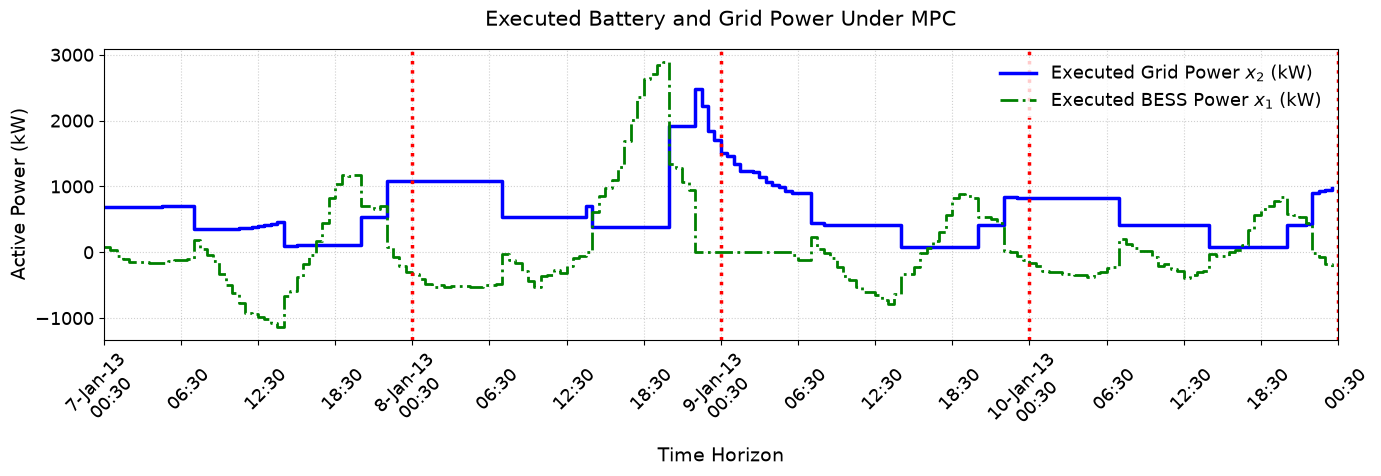

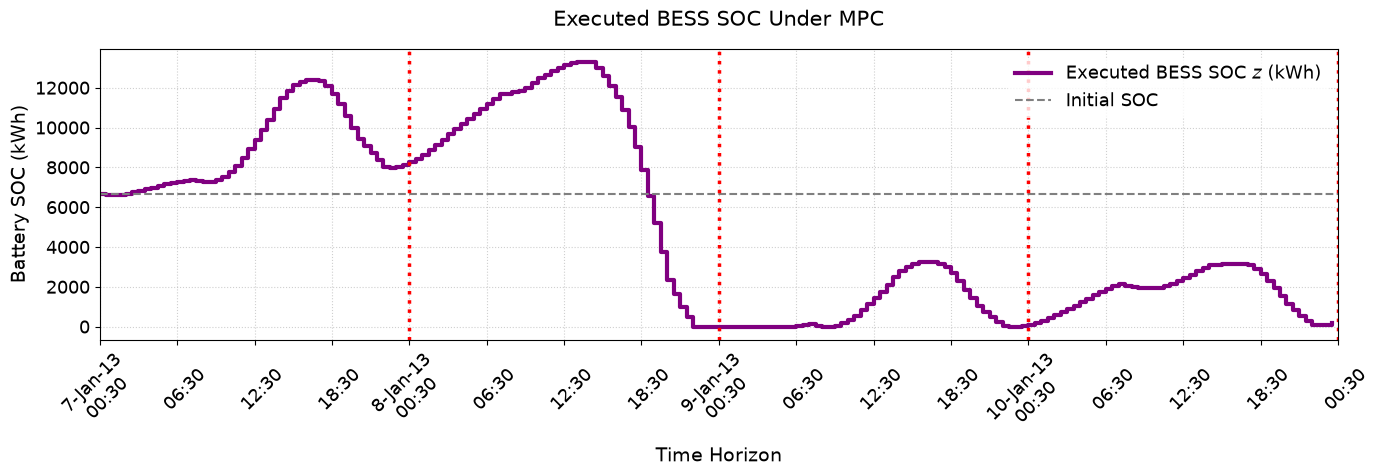

In [2]:
"""
Main Execution
"""

steps_per_day = 48
delta = 0.5

load_csv_path = 'perfect_load.csv'
pv_csv_path = 'perfect_pv.csv'
load_profiles, pv_profiles, total_days, dates = read_load_generation(load_csv_path, pv_csv_path)

pred_days = 1
N_pred = pred_days * steps_per_day
sim_days = total_days - pred_days
sim_steps = sim_days * steps_per_day

eta_profiles = generate_eta_profiles(total_days, steps_per_day)

total_customers = 1330
p_min = -5.0 * total_customers
p_max = 5.0 * total_customers
c_max = 10.0 * total_customers
z_init = 5.0 * total_customers

w = 1.0

all_x1_BESS, all_x2_grid, all_z_SOC = run_mpc_loop(
    sim_steps, N_pred, delta,
    load_profiles, pv_profiles, eta_profiles,
    p_min, p_max, c_max, z_init, w
)

time_indices_sim = np.arange(sim_steps)
timeline_sim = time_indices_sim * delta
plot_results(
    timeline_sim, load_profiles, pv_profiles, eta_profiles,
    all_x1_BESS, all_x2_grid, all_z_SOC, p_max, c_max, sim_days, delta, dates
)
